<a href="https://colab.research.google.com/github/IKM-Products/Concrete-Strength-Prediction-Using-Machine-Learning-Regression-Algorithms/blob/main/Concrete_Strength_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# Install XGBoost library
!pip install xgboost

# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import joblib for saving and loading trained models
import joblib

# Import utilities for data splitting, cross-validation, and hyperparameter tuning
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import Decision Tree Regressor model
from sklearn.tree import DecisionTreeRegressor

# Import Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

# Import Gradient Boosting Regressor model
from sklearn.ensemble import GradientBoostingRegressor

# Import XGBoost Regressor model
from xgboost import XGBRegressor

# Import evaluation metrics for regression models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the concrete compressive strength dataset
df = pd.read_csv("Concrete Compressive Strength.csv")

In [4]:
# Display the first 5 rows of the dataset
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [5]:
# Display the number of rows and columns in the dataset
df.shape

(1030, 9)

In [6]:
# Display information about the dataset, including column names,
# data types, non-null values, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Cement                          1030 non-null   float64
 1   Blast Furnace Slag              1030 non-null   float64
 2   Fly Ash                         1030 non-null   float64
 3   Water                           1030 non-null   float64
 4   Superplasticizer                1030 non-null   float64
 5   Coarse Aggregate                1030 non-null   float64
 6   Fine Aggregate                  1030 non-null   float64
 7   Age (day)                       1030 non-null   int64  
 8   Concrete compressive strength   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
# Generate descriptive statistics for numerical columns,
# including count, mean, standard deviation, minimum,
# maximum, and quartile values
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [9]:
# Check for missing (null) values in each column of the dataset
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [10]:
# Check for infinite values in each column of the dataset
np.isinf(df).sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [11]:
# Count the number of zero values in each column of the dataset
(df == 0).sum()

,0
Cement,0
Blast Furnace Slag,466
Fly Ash,566
Water,0
Superplasticizer,379
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [12]:
# Count the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(25)

In [13]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Verify duplicate rows after removal
print(df.duplicated().sum())
print(df.shape)

0
(1005, 9)


In [14]:
# Separate the input features (X) and target variable (y)
X = df.drop("Concrete compressive strength ", axis=1)
y = df["Concrete compressive strength "]

In [16]:
# Calculate Q1 and Q3
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers in each feature
outlier_count = ((X < lower_bound) | (X > upper_bound)).sum()

print("Outliers in each feature:")
print(outlier_count)

Outliers in each feature:
Cement                 0
Blast Furnace Slag     2
Fly Ash                0
Water                 15
Superplasticizer      10
Coarse Aggregate       0
Fine Aggregate         5
Age (day)             59
dtype: int64


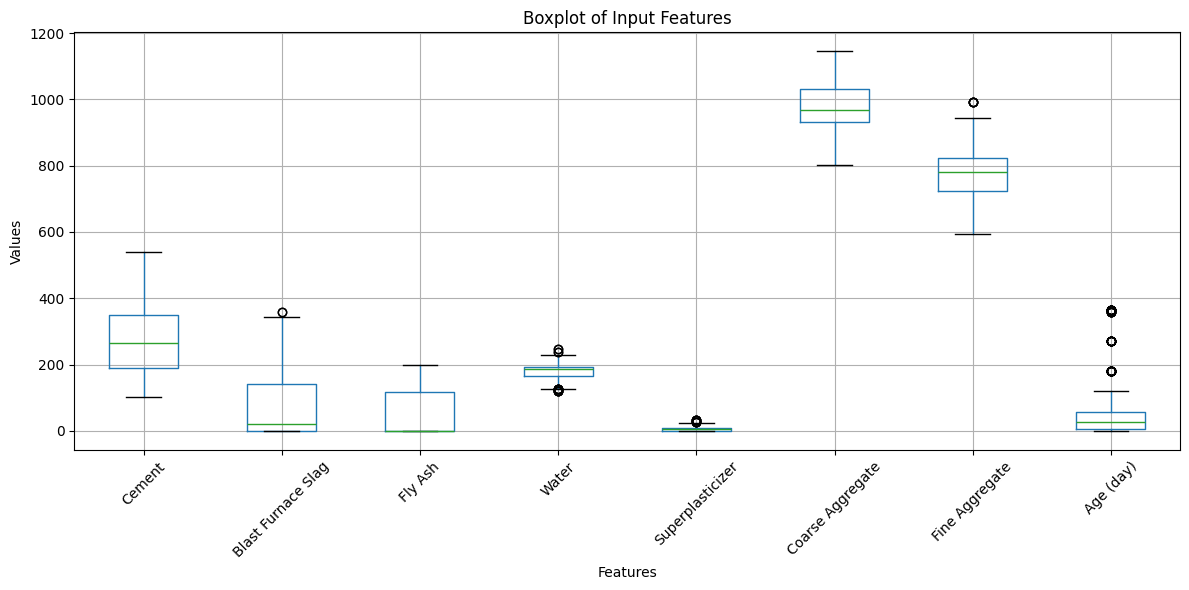

In [17]:
# Visualize feature distributions and identify outliers across all input variables using boxplots
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

X.boxplot()

plt.title("Boxplot of Input Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

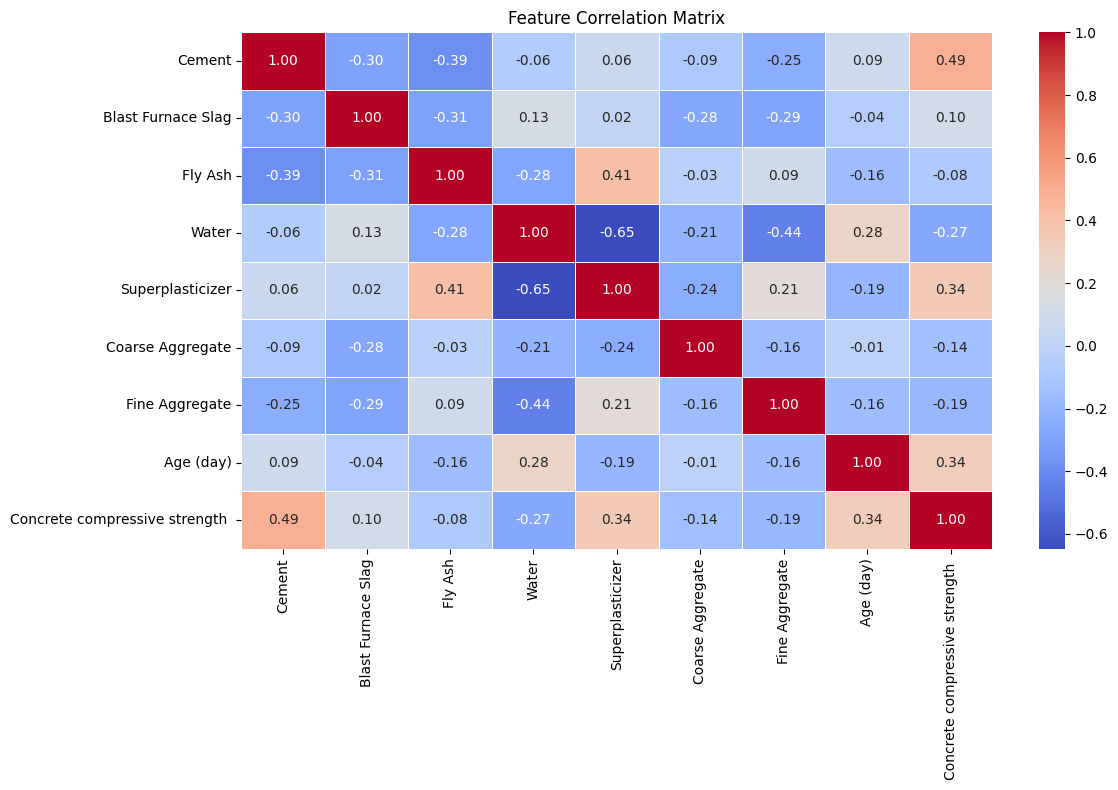

In [19]:
# Compute and plot a heatmap of the correlation matrix to inspect pairwise relationships among numerical features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler only on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the parameters learned from training data
X_test_scaled = scaler.transform(X_test)

print("Train-Test Split and Feature Scaling completed")

Train-Test Split and Feature Scaling completed


In [23]:
# Create a Linear Regression model
lr_model = LinearRegression()

# Fit the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# Make predictions on scaled test data
lr_pred = lr_model.predict(X_test_scaled)

In [26]:
# Create a Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
dt_pred = dt_model.predict(X_test)

In [27]:
# Create a Random Forest Regressor model with 200 decision trees
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [28]:
# Create a Gradient Boosting Regressor model with specified hyperparameters
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [29]:
# Create an XGBoost Regressor model with specified hyperparameters
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [30]:
# Create a DataFrame containing new concrete mix samples to predict compressive strength on unseen data
new_samples = pd.DataFrame({
    "Cement": [540, 332],
    "Blast Furnace Slag": [0, 142],
    "Fly Ash": [0, 50],
    "Water": [162, 228],
    "Superplasticizer": [2.5, 0],
    "Coarse Aggregate": [1040, 932],
    "Fine Aggregate": [676, 594],
    "Age (day)": [28, 90]
})

In [33]:
new_samples_scaled = scaler.transform(new_samples)

# Linear Regression prediction
lr_prediction = lr_model.predict(new_samples_scaled)

# Decision Tree prediction
dt_prediction = dt_model.predict(new_samples)

# Random Forest prediction
rf_prediction = rf_model.predict(new_samples)

# Gradient Boosting prediction
gb_prediction = gb_model.predict(new_samples)

# XGBoost prediction
xgb_prediction = xgb_model.predict(new_samples)

print("Linear Regression Predictions:", lr_prediction, "MPa")
print("Decision Tree Predictions:", dt_prediction, "MPa")
print("Random Forest Predictions:", rf_prediction, "MPa")
print("Gradient Boosting Predictions:", gb_prediction, "MPa")
print("XGBoost Predictions:", xgb_prediction, "MPa")

Linear Regression Predictions: [52.36196738 40.23086754] MPa
Decision Tree Predictions: [79.98611076 37.72192144] MPa
Random Forest Predictions: [73.59225507 37.95989753] MPa
Gradient Boosting Predictions: [71.82594671 42.04368489] MPa
XGBoost Predictions: [73.69065  39.758186] MPa


In [35]:
# Define a helper function to calculate and print evaluation metrics (MAE, RMSE, R2 Score) for regression models
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("----------------------")

In [36]:
# Evaluate all models

evaluate_model("Linear Regression", y_test, lr_pred)

evaluate_model("Decision Tree Regressor", y_test, dt_pred)

evaluate_model("Random Forest Regressor", y_test, rf_pred)

evaluate_model("Gradient Boosting Regressor", y_test, gb_pred)

evaluate_model("XGBoost Regressor", y_test, xgb_pred)

Linear Regression
MAE: 8.896027820702948
RMSE: 11.192199885588051
R2 Score: 0.5801089019841734
----------------------
Decision Tree Regressor
MAE: 3.96084605720398
RMSE: 6.317237134098993
R2 Score: 0.866229573723519
----------------------
Random Forest Regressor
MAE: 3.4885639853826964
RMSE: 5.152688066104909
R2 Score: 0.9110033917355721
----------------------
Gradient Boosting Regressor
MAE: 4.098667525792584
RMSE: 5.519769588900979
R2 Score: 0.8978713360146136
----------------------
XGBoost Regressor
MAE: 3.2339894337503514
RMSE: 4.716134835737565
R2 Score: 0.9254447590246048
----------------------


In [40]:
from sklearn.pipeline import make_pipeline

# Define 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression with scaling
lr_cv = cross_val_score(
    make_pipeline(StandardScaler(), LinearRegression()),
    X, y,
    cv=kfold,
    scoring="r2"
)

# Decision Tree
dt_cv = cross_val_score(
    dt_model,
    X, y,
    cv=kfold,
    scoring="r2"
)

# Random Forest
rf_cv = cross_val_score(
    rf_model,
    X, y,
    cv=kfold,
    scoring="r2"
)

# Gradient Boosting
gb_cv = cross_val_score(
    gb_model,
    X, y,
    cv=kfold,
    scoring="r2"
)

# XGBoost
xgb_cv = cross_val_score(
    xgb_model,
    X, y,
    cv=kfold,
    scoring="r2"
)

# Display Cross-Validation Results
print("Linear Regression CV Mean:", lr_cv.mean())
print("Linear Regression CV Std:", lr_cv.std())
print("----------------------")

print("Decision Tree CV Mean:", dt_cv.mean())
print("Decision Tree CV Std:", dt_cv.std())
print("----------------------")

print("Random Forest CV Mean:", rf_cv.mean())
print("Random Forest CV Std:", rf_cv.std())
print("----------------------")

print("Gradient Boosting CV Mean:", gb_cv.mean())
print("Gradient Boosting CV Std:", gb_cv.std())
print("----------------------")

print("XGBoost CV Mean:", xgb_cv.mean())
print("XGBoost CV Std:", xgb_cv.std())

Linear Regression CV Mean: 0.5938951856365566
Linear Regression CV Std: 0.03371586634035132
----------------------
Decision Tree CV Mean: 0.8490000657022196
Decision Tree CV Std: 0.02797338701626862
----------------------
Random Forest CV Mean: 0.9100708051166506
Random Forest CV Std: 0.007792698007446927
----------------------
Gradient Boosting CV Mean: 0.8972188287953579
Gradient Boosting CV Std: 0.015575416701598293
----------------------
XGBoost CV Mean: 0.9247233539529398
XGBoost CV Std: 0.009575400201357553


In [41]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "Test R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, xgb_pred)
    ],
    "CV R2 Mean": [
        lr_cv.mean(),
        dt_cv.mean(),
        rf_cv.mean(),
        gb_cv.mean(),
        xgb_cv.mean()
    ],
    "CV R2 Std": [
        lr_cv.std(),
        dt_cv.std(),
        rf_cv.std(),
        gb_cv.std(),
        xgb_cv.std()
    ]
})

print(comparison.round(4))

               Model     MAE     RMSE  Test R2  CV R2 Mean  CV R2 Std
0  Linear Regression  8.8960  11.1922   0.5801      0.5939     0.0337
1      Decision Tree  3.9608   6.3172   0.8662      0.8490     0.0280
2      Random Forest  3.4886   5.1527   0.9110      0.9101     0.0078
3  Gradient Boosting  4.0987   5.5198   0.8979      0.8972     0.0156
4            XGBoost  3.2340   4.7161   0.9254      0.9247     0.0096


In [42]:
best_model = comparison.loc[comparison["Test R2"].idxmax()]

print("Best Model:", best_model["Model"])
print("Test R2:", best_model["Test R2"])
print("CV R2 Mean:", best_model["CV R2 Mean"])

Best Model: XGBoost
Test R2: 0.9254447590246048
CV R2 Mean: 0.9247233539529398


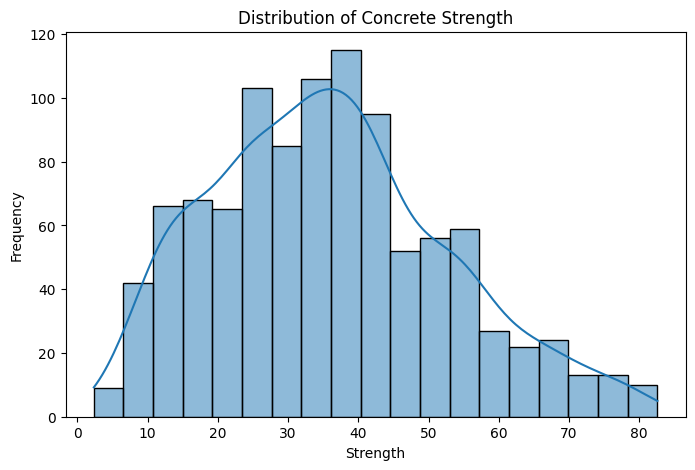

In [53]:
#Target distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Concrete compressive strength "],
    kde=True
)

plt.title("Distribution of Concrete Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")

plt.show()

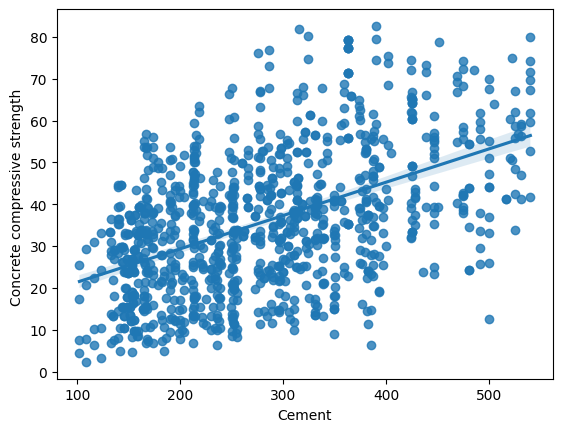

In [54]:
#Cement vs Strength
sns.regplot(
    x=df["Cement"],
    y=df["Concrete compressive strength "]
)

plt.show()

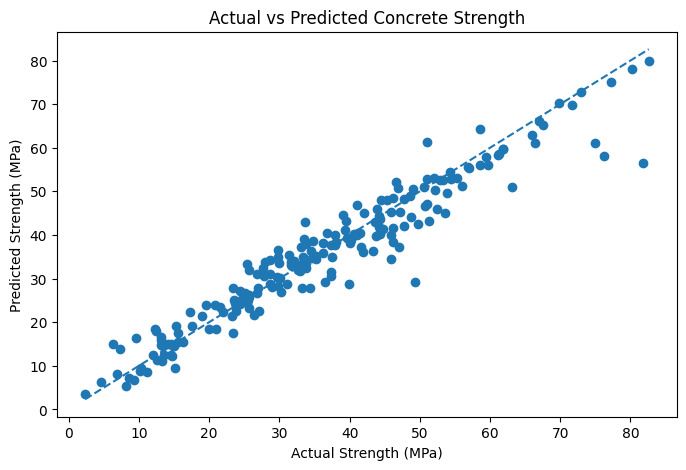

In [44]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8,5))

plt.scatter(y_test, xgb_pred)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted Concrete Strength")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

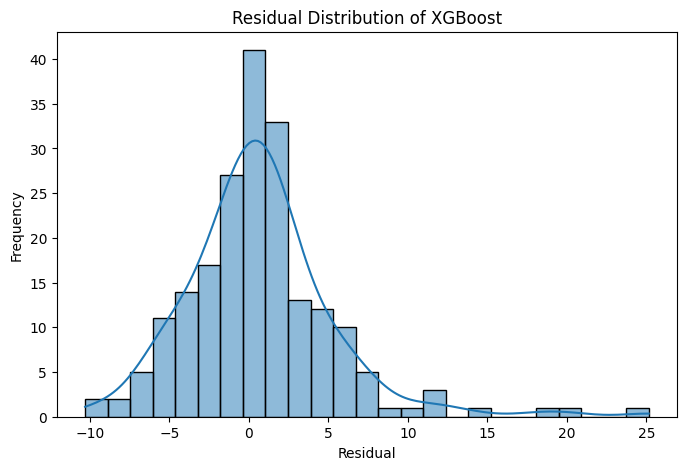

In [46]:
# Residual analysis
plt.figure(figsize=(8,5))

# Calculate residuals
residuals = y_test - xgb_pred

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution of XGBoost")

plt.show()

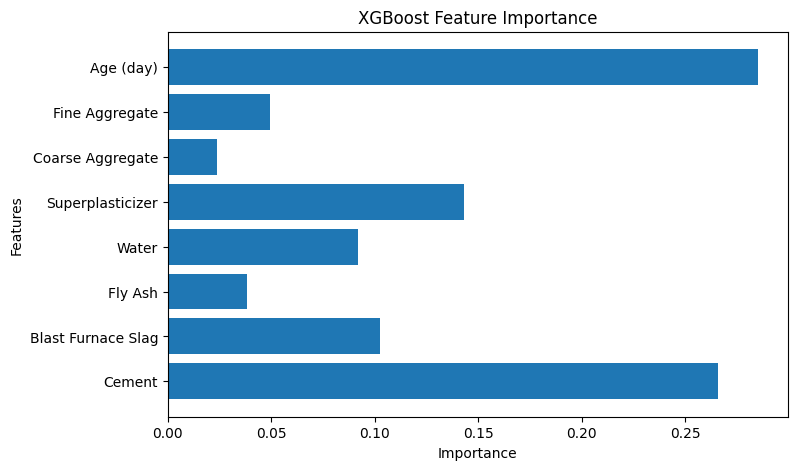

In [47]:
#XGBoost Feature importance
importance = xgb_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.show()

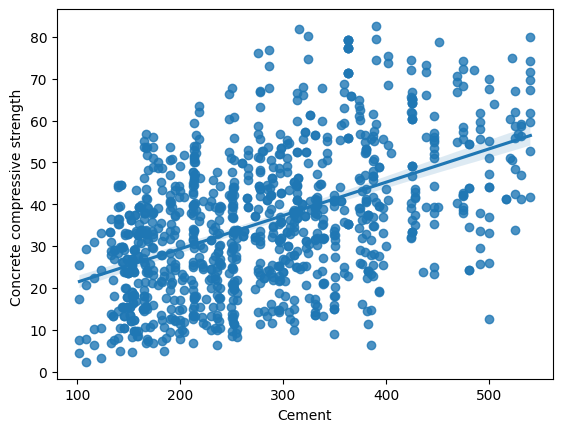

In [52]:
#Cement vs Strength
sns.regplot(
    x=df["Cement"],
    y=df["Concrete compressive strength "]
)

plt.show()

In [61]:
# Tune XGBoost hyperparameters using grid search with 5-fold cross-validation
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)



Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best CV R2: 0.9234130179487134


In [62]:
# Tuned XGBoost Prediction

best_xgb_model = grid_search.best_estimator_

tuned_xgb_pred = best_xgb_model.predict(X_test)

print("Tuned XGBoost Prediction Completed")

Tuned XGBoost Prediction Completed


In [63]:
# Tuned XGBoost Evaluation

tuned_mae = mean_absolute_error(y_test, tuned_xgb_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))
tuned_r2 = r2_score(y_test, tuned_xgb_pred)

print("Tuned XGBoost Performance")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2 Score:", tuned_r2)

Tuned XGBoost Performance
MAE: 2.648213081505744
RMSE: 4.0987031988984555
R2 Score: 0.9436882929010236


In [64]:
# Compare Original vs Tuned XGBoost

comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, tuned_xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))
    ],
    "R2 Score": [
        r2_score(y_test, xgb_pred),
        r2_score(y_test, tuned_xgb_pred)
    ]
})

print(comparison.round(4))

              Model     MAE    RMSE  R2 Score
0  Original XGBoost  3.2340  4.7161    0.9254
1     Tuned XGBoost  2.6482  4.0987    0.9437


In [65]:
# Final Model Selection

final_model = best_xgb_model

print("Final Model: Tuned XGBoost")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2 Score:", tuned_r2)

Final Model: Tuned XGBoost
MAE: 2.648213081505744
RMSE: 4.0987031988984555
R2 Score: 0.9436882929010236


In [68]:
# Save original models
joblib.dump(lr_model, "linear_regression.pkl")
joblib.dump(dt_model, "decision_tree.pkl")
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(gb_model, "gradient_boosting.pkl")
joblib.dump(xgb_model, "xgboost.pkl")

# Save tuned XGBoost
joblib.dump(best_xgb_model, "tuned_xgboost.pkl")

# Save scaler used for Linear Regression
joblib.dump(scaler, "scaler.pkl")

print("All models and scaler saved successfully.")

All models and scaler saved successfully.
